<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana4/LimpiezaBase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir('/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana3')
!ls


Datos				     Pandas_EstudioExploratorio.ipynb
PandasBasico_COVID_EDA_Modelo.ipynb  ProbabilidadKDE.ipynb


1. "age" (Edad) numérica
2. "job" (Trabajo) categórica
3. "marital" (Estado civil) categórica
4. "education" (Nivel educativo) categórica
5. "default" (Si dejo de pagar) categórico
6. "balance" (saldo promedio) numérico
7. "housing" (Credito hipotecario) categórico
8. "loan" (Creditos de consumo) categórico
9. "contact" (Medio de contacto) categórico
10. "day" (último día en que fue contactado) numérica
11. "month" (último més en que fue contactado) categórica
12. "duration" (Duración de última llamada en segundos) numérica
13. "campaign" (Numero total de veces en ser contactado) numérica
14. "pdays" (Número de dias después de haber sido contactado) numérica
15. "previous" (Número de veces de ser conctactado antes de la presente campaña) numérica
16. "poutcome" (Resultado de la campaña anterior) categórica
17. "y" (El cliente suscribió el deposito) categórica

In [3]:
data = pd.read_csv('Datos/Banco.csv')
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45211,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45212,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45213,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


In [4]:
# Necesitamos las variables categoricas
col_cate = ['job', 'marital', 'education', 'default','housing','loan','contact','month','poutcome','y']
col_cate

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [5]:
col_num = ['age','balance','day','duration','campaign','pdays','previous']
col_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


In [7]:
# Vamos a eliminar los valores no nulos
# El tamaño de la base, información extra para interpolar
data.dropna(inplace=True) # reescribir el espacio en memoria original
# Muy util

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  object 
 2   marital    45207 non-null  object 
 3   education  45207 non-null  object 
 4   default    45207 non-null  object 
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  object 
 7   loan       45207 non-null  object 
 8   contact    45207 non-null  object 
 9   day        45207 non-null  int64  
 10  month      45207 non-null  object 
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  object 
 16  y          45207 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 6.2+ MB


In [9]:
# Mirar lo registro duplicados
data.duplicated().sum()

np.int64(4)

In [10]:
data.drop_duplicates(inplace=True)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45203 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45203 non-null  int64  
 1   job        45203 non-null  object 
 2   marital    45203 non-null  object 
 3   education  45203 non-null  object 
 4   default    45203 non-null  object 
 5   balance    45203 non-null  float64
 6   housing    45203 non-null  object 
 7   loan       45203 non-null  object 
 8   contact    45203 non-null  object 
 9   day        45203 non-null  int64  
 10  month      45203 non-null  object 
 11  duration   45203 non-null  float64
 12  campaign   45203 non-null  int64  
 13  pdays      45203 non-null  float64
 14  previous   45203 non-null  int64  
 15  poutcome   45203 non-null  object 
 16  y          45203 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 6.2+ MB


In [12]:
#Como llamamos las columnas
data.keys()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [13]:
# Los subniveles categoricos:
# -> si son unicos -> la base esta bien construida
# -> si no son unicos -> la base tiene problemas

In [14]:
for col in col_cate:
  print(f"{col}: {data[col].unique()}, {len(data[col].unique())}")

job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'Management' 'retired' 'admin.' 'services' 'self-employed' 'MANAGEMENT'
 'Self-employed' 'unemployed' 'housemaid' 'student' 'Services' 'Retired'
 'administrative'], 18
marital: ['married' 'single' 'div.' 'divorced' 'DIVORCED' 'Single'], 6
education: ['tertiary' 'secondary' 'unknown' 'primary' 'SECONDARY' 'Secondary'
 'Primary' 'sec.' 'Tertiary' 'UNK'], 10
default: ['no' 'yes'], 2
housing: ['yes' 'no'], 2
loan: ['no' 'yes' 'No' 'YES' 'Yes' 'NO'], 6
contact: ['unknown' 'cellular' 'telephone' 'phone' 'mobile'], 5
month: ['may' 'nov' 'jun' 'jul' 'aug' 'oct' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep'], 12
poutcome: ['unknown' 'UNK' 'failure' 'other' 'success' 'Success'], 6
y: ['no' 'yes'], 2


In [15]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45203.000000,45203.000000,45203.000000,45203.000000,45203.000000,45203.000000,45203.000000
mean,41.005177,1373.893967,15.807115,258.039754,2.763843,40.177709,0.580138
std,12.037387,3923.852086,8.323018,257.470045,3.098168,100.104768,2.303344
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


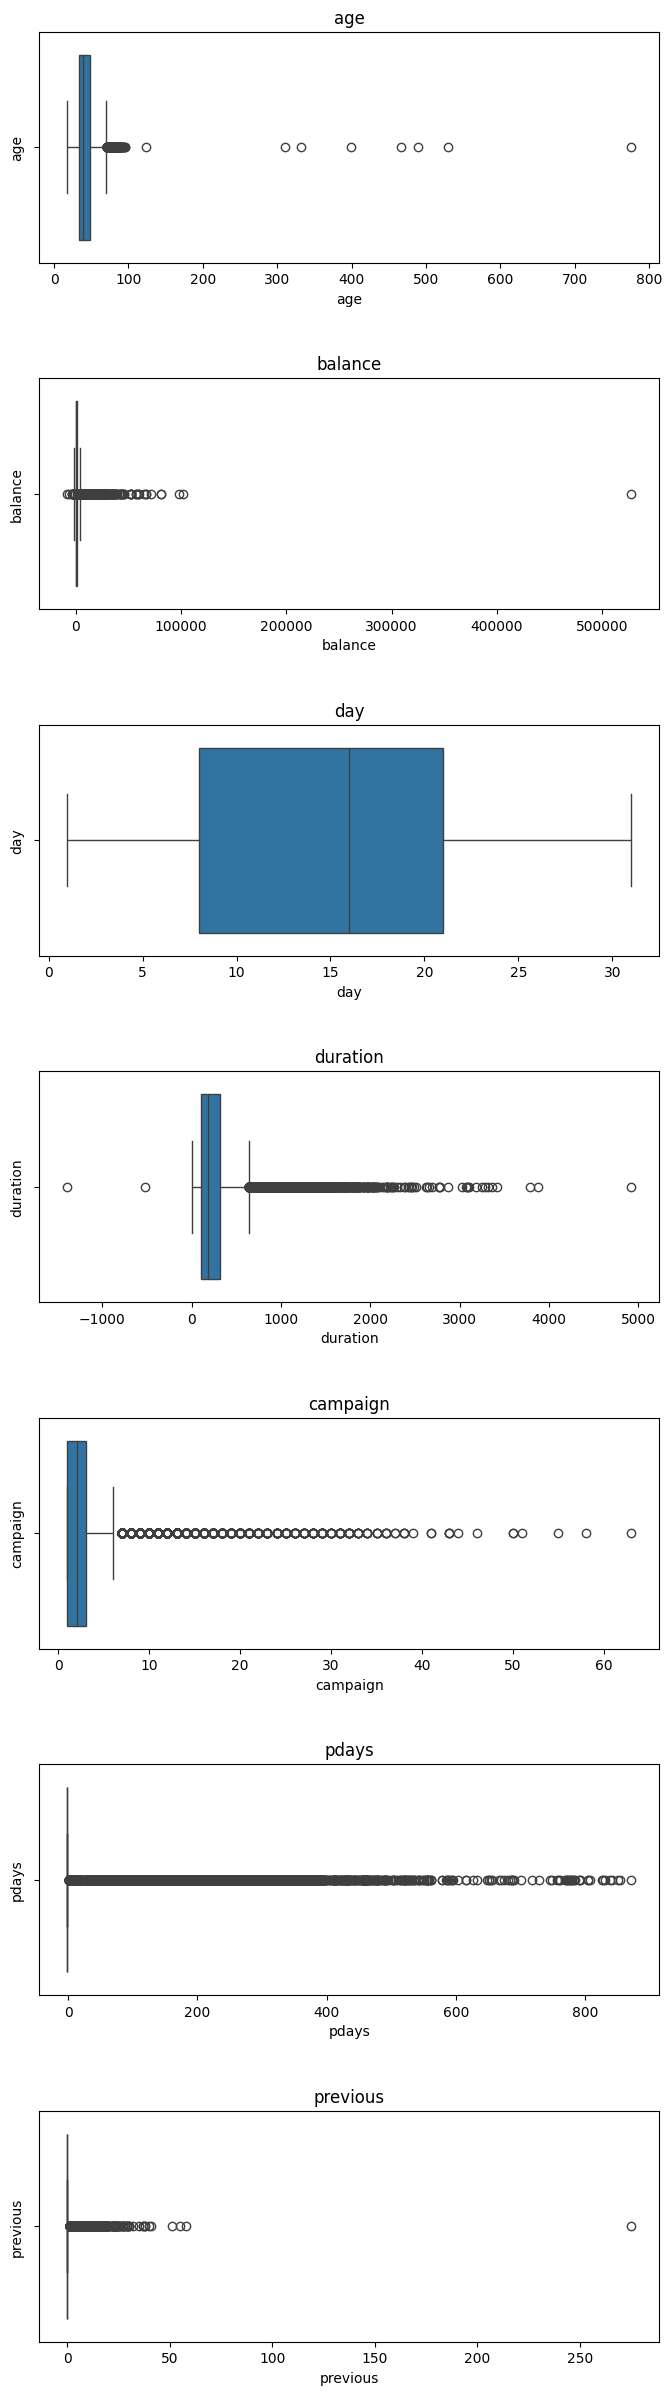

In [16]:
fig, ax = plt.subplots( len(col_num), 1, figsize=(8,30) )
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_num): # sobre enumeracion
  sns.boxplot(data=data, x=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_ylabel(col)

In [17]:
# Filtrado , masking
mask = data['balance'] > 400000
data[mask]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2214,56,admin.,married,secondary,no,527532.0,yes,no,unknown,12,may,146.0,1,-1.0,0,unknown,no


In [18]:
print(data.shape)
mask1 = data['age'] <= 100
data = data[mask1]
print(data.shape)

(45203, 17)
(45195, 17)


In [19]:
print(data.shape)
mask2 = data['duration'] >= 0
data = data[mask2]
print(data.shape)

(45195, 17)
(45193, 17)


In [20]:
print(data.shape)
mask3 = data['previous'] <= 100
data = data[mask3]
print(data.shape)

(45193, 17)
(45192, 17)


/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used 

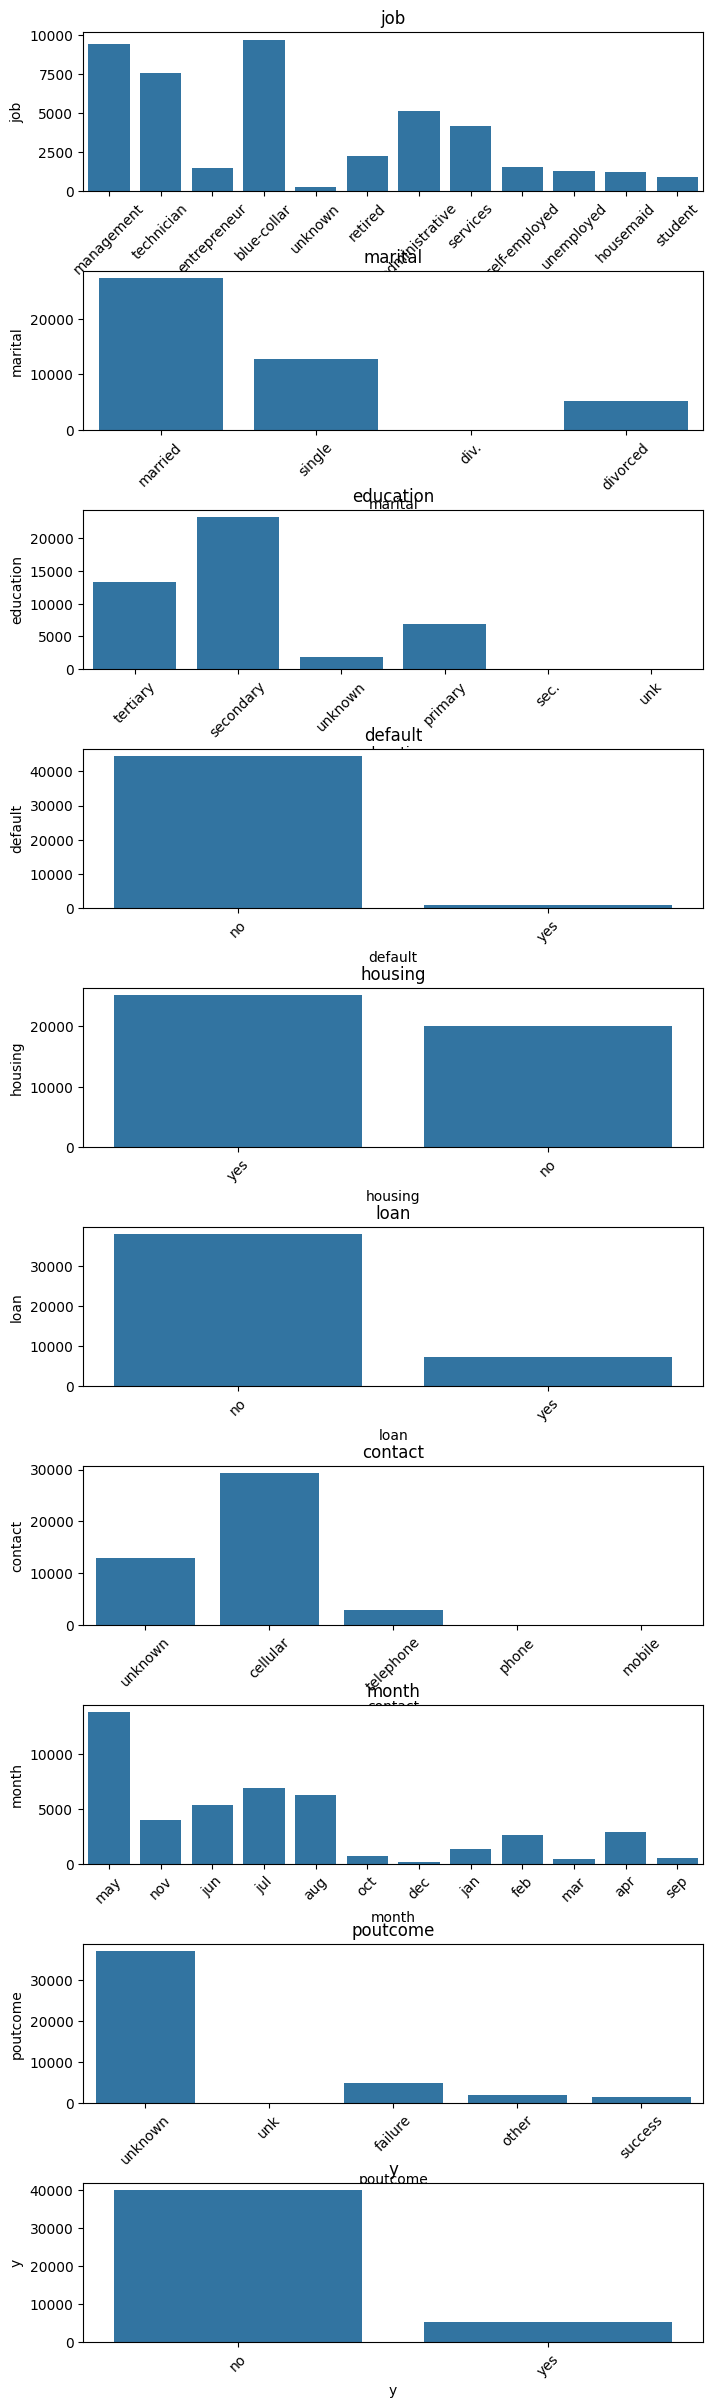

In [28]:
fig, ax = plt.subplots( len(col_cate), 1, figsize=(8,30) )
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_cate): # sobre enumeracion
  sns.countplot(x=col, data=data, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_ylabel(col)
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)

In [25]:
for column in data.columns:

  if column in col_cate:
    print(column)
    data[column] = data[column].str.lower()

job
marital
education
default
housing
loan
contact
month
poutcome
y


In [27]:
data['job'] = data['job'].str.replace('admin.','administrative',regex=False)

In [29]:
data['marital'] = data['marital'].str.replace('div.','divorced',regex=False)
data['marital'].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [30]:
data['education'] = data['education'].str.replace('sec.','secondary',regex=False)
data['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary', 'unk'], dtype=object)

In [31]:
data.education = data.education.replace({'unk':'unknown'})

In [32]:
data['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [33]:
data.contact = data.contact.replace({'phone':'telephone'})

In [34]:
data.poutcome = data.poutcome.replace({'unk':'unknown'})

/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_11067/3261979481.py:8: UserWarning: set_ticklabels() should only be used 

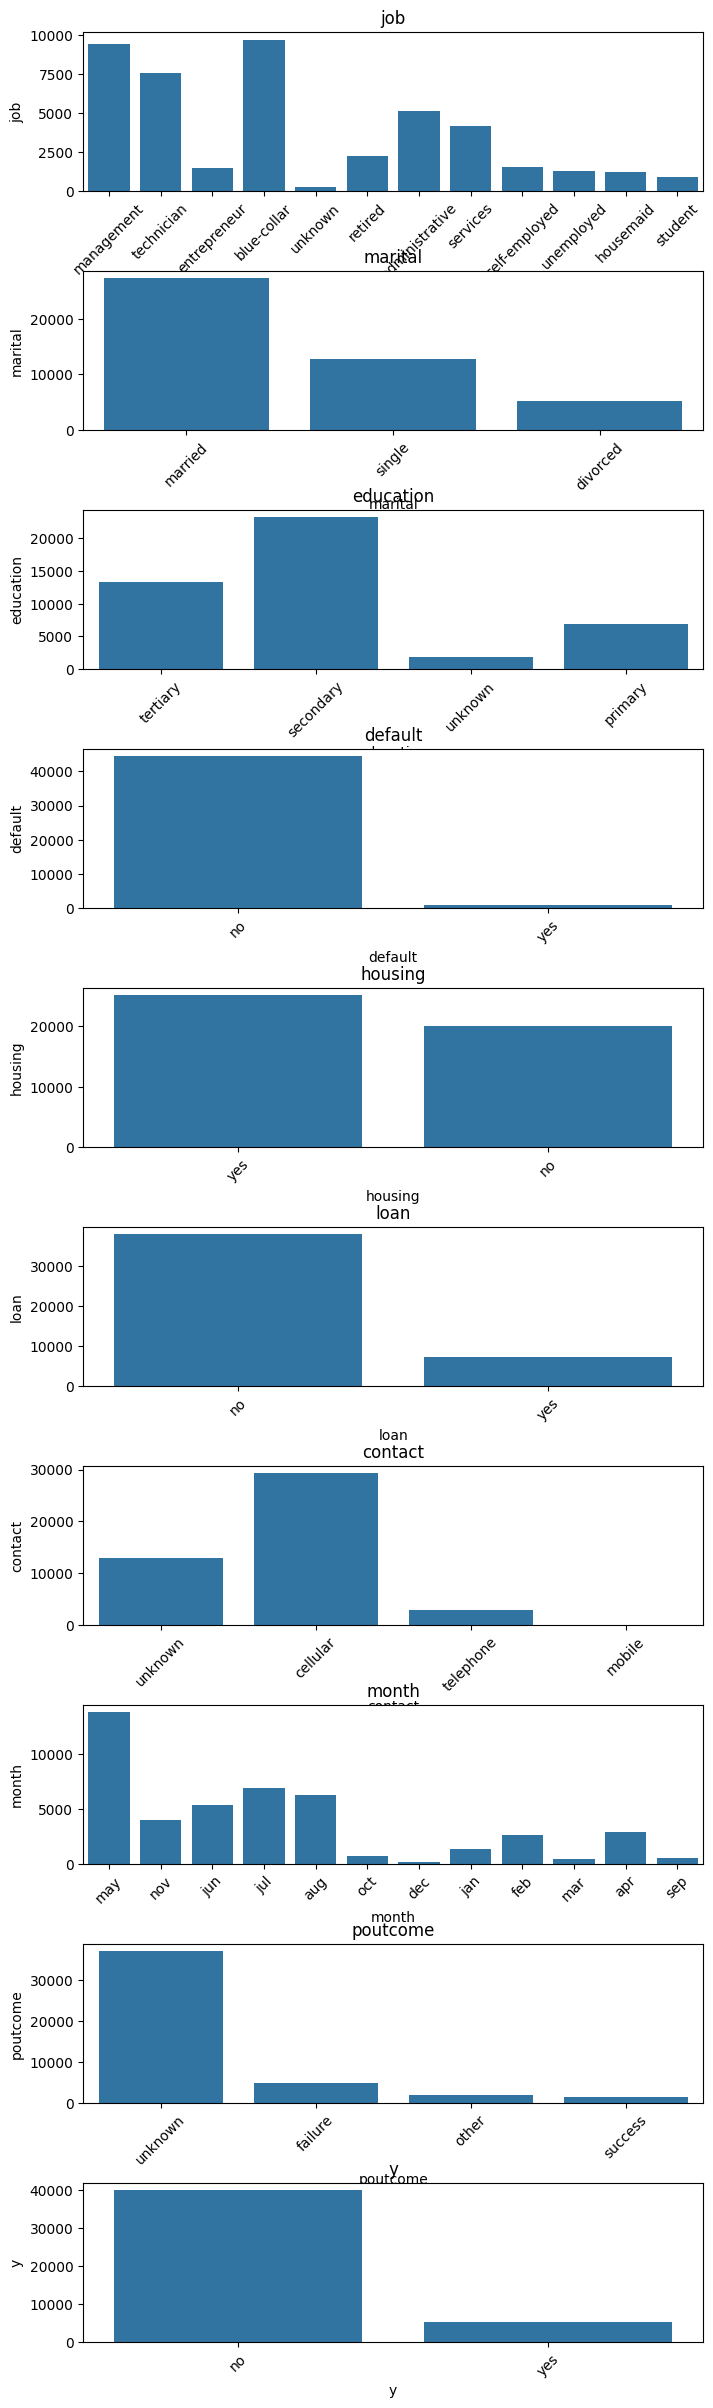

In [35]:
fig, ax = plt.subplots( len(col_cate), 1, figsize=(8,30) )
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_cate): # sobre enumeracion
  sns.countplot(x=col, data=data, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_ylabel(col)
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)

In [36]:
data.to_csv('Datos/BancoFinal.csv',index=False)